### Importation of the libraries 

In [1]:
%pip install numpy 
%pip install pandas 
%pip install matplotlib 
%pip install seaborn 
%pip install scikit-learn 
%pip install torch 
%pip install scikit-optimize 
%pip install xgboost
%pip install openpyxl
%pip install tabulate
%pip install statsmodels
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier 
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import RepeatedStratifiedKFold
from skopt.space import Real, Integer
from skopt import BayesSearchCV
from xgboost import XGBClassifier
import openpyxl

### Loading the Data

In [3]:
df = pd.read_excel("Pups_Analyse NTs_221124.xlsx", sheet_name="NT-R-stack")

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Projet                108 non-null    str    
 1   Cohort                108 non-null    str    
 2   Group                 108 non-null    str    
 3   Cage                  60 non-null     str    
 4   ID                    81 non-null     object 
 5   ID.2                  81 non-null     object 
 6   Sample Name           108 non-null    str    
 7   Sex                   108 non-null    str    
 8   Area                  108 non-null    str    
 9   5HTP                  101 non-null    float64
 10  Adénosine             108 non-null    float64
 11  Adrénaline            3 non-null      float64
 12  Dopamine              67 non-null     float64
 13  GABA                  108 non-null    float64
 14  Glutamate             108 non-null    float64
 15  Glutamine aire brute  108 non-null

## Cleaning / Preparation / Visualisation of the Data

### Cleaning the Data 

In [5]:
df = df[
    ~(
        ((df['Tryptophane']<15) & (df['Tyrosine'] > 40))
    )
]

In [6]:
print(f"The columns in the dataset are: {df.columns}")

The columns in the dataset are: Index(['Projet', 'Cohort', 'Group', 'Cage', 'ID', 'ID.2', 'Sample Name', 'Sex',
       'Area', '5HTP', 'Adénosine', 'Adrénaline', 'Dopamine', 'GABA',
       'Glutamate', 'Glutamine aire brute', 'Glutamine/Sero d4', 'Kynurénine',
       'Noradrénaline', 'Normétanéphrine', 'Sérotonine', 'Tryptophane',
       'Tyramine', 'Tyrosine'],
      dtype='str')


### Separation of the Data by Area

In [7]:
NT_df_pfc_juv = df.query("Area == 'PFC'").copy()
NT_df_hip_juv = df.query("Area == 'HIP'").copy()
NT_df_str_juv = df.query("Area == 'STR'").copy()

Now, for the number of individuals in each group for each Area.

In [8]:
print(f" --In the PFC group--:",NT_df_pfc_juv['Group'].value_counts())
print(f" --In the HIP group-- :",NT_df_hip_juv['Group'].value_counts())
print(f" --In the STR group-- :",NT_df_str_juv['Group'].value_counts())

 --In the PFC group--: Group
CONT    18
LBN     15
Name: count, dtype: int64
 --In the HIP group-- : Group
LBN     21
CONT    21
Name: count, dtype: int64
 --In the STR group-- : Group
CONT    18
LBN     14
Name: count, dtype: int64


Now, the count of individuals broken down by sex cohort and cage, per area.

---

#### For the PFC 

In [9]:
print("For the PFC Area : ")
print(
    NT_df_pfc_juv
    .groupby(['Group', 'Sex', 'Cohort', 'Cage'], dropna=False)
    .size()
    .reset_index(name='N')
)

For the PFC Area : 
   Group     Sex    Cohort Cage  N
0   CONT  female  Cohort 1    D  3
1   CONT  female  Cohort 2  NaN  1
2   CONT  female    July24  NaN  4
3   CONT    male  Cohort 1    D  2
4   CONT    male  Cohort 2  NaN  3
5   CONT    male    July24  NaN  5
6    LBN  female  Cohort 1    A  1
7    LBN  female  Cohort 1    C  5
8    LBN  female  Cohort 2  NaN  2
9    LBN    male  Cohort 1    A  6
10   LBN    male  Cohort 2  NaN  1


---

#### For the HIP

In [10]:
print("\nFor the HIP Area :")
print(
    NT_df_hip_juv
    .groupby(['Group', 'Sex', 'Cohort', 'Cage'], dropna=False)
    .size()
    .reset_index(name='N')
)


For the HIP Area :
   Group     Sex    Cohort Cage  N
0   CONT  female  Cohort 0    E  2
1   CONT  female  Cohort 1    D  3
2   CONT  female  Cohort 2  NaN  1
3   CONT  female    July24  NaN  4
4   CONT    male  Cohort 0    E  1
5   CONT    male  Cohort 1    D  2
6   CONT    male  Cohort 2  NaN  3
7   CONT    male    July24  NaN  5
8    LBN  female  Cohort 0    G  3
9    LBN  female  Cohort 1    A  1
10   LBN  female  Cohort 1    C  5
11   LBN  female  Cohort 2  NaN  2
12   LBN    male  Cohort 0    G  3
13   LBN    male  Cohort 1    A  6
14   LBN    male  Cohort 2  NaN  1


---

#### For the STR

In [11]:
print("\nFor the STR Area :")
print(
    NT_df_str_juv
    .groupby(['Group', 'Sex', 'Cohort', 'Cage'], dropna=False)
    .size()
    .reset_index(name='N')
)


For the STR Area :
   Group     Sex    Cohort Cage  N
0   CONT  female  Cohort 1    D  3
1   CONT  female  Cohort 2  NaN  1
2   CONT  female    July24  NaN  4
3   CONT    male  Cohort 1    D  2
4   CONT    male  Cohort 2  NaN  3
5   CONT    male    July24  NaN  5
6    LBN  female  Cohort 1    A  1
7    LBN  female  Cohort 1    C  4
8    LBN  female  Cohort 2  NaN  2
9    LBN    male  Cohort 1    A  6
10   LBN    male  Cohort 2  NaN  1


### Seperation of the Data into 2 Dataset : X (Predictors) and Y (Outcome)

In [12]:
columns_to_drop = ['Projet','Cohort','Group','Cage','ID','ID.2','Sample Name','Sex','Area','Dopamine','Adrénaline','Glutamine aire brute']
Y_juv_pfc = NT_df_pfc_juv['Group'].replace({'CONT': 0, 'LBN': 1}).astype(int)
X_juv_pfc = NT_df_pfc_juv.drop(columns=columns_to_drop)
Y_juv_hip = NT_df_hip_juv['Group'].replace({'CONT': 0, 'LBN': 1}).astype(int)
X_juv_hip = NT_df_hip_juv.drop(columns=columns_to_drop)
Y_juv_str = NT_df_str_juv['Group'].replace({'CONT': 0, 'LBN': 1}).astype(int)
X_juv_str = NT_df_str_juv.drop(columns=columns_to_drop)

In [13]:
NT_df_pfc_juv.head()

,Projet,Cohort,Group,Cage,ID,ID.2,Sample Name,Sex,Area,5HTP,...,Glutamate,Glutamine aire brute,Glutamine/Sero d4,Kynurénine,Noradrénaline,Normétanéphrine,Sérotonine,Tryptophane,Tyramine,Tyrosine
0,VEAVE,Cohort 1,LBN,A,1,A1,Souris_LBN A1,female,PFC,0.07121,...,5.624,34790000,115.70,0.000358,0.5434,1.1470,0.1690,17.2300,0.12430,72.290
1,VEAVE,Cohort 1,LBN,A,2,A2,Souris_LBN A2,male,PFC,NaN,...,3.372,65870000,353.20,0.000348,0.4457,1.2480,0.2482,1.6210,0.02929,9.920
2,VEAVE,Cohort 1,LBN,A,3,A3,Souris_LBN A3,male,PFC,0.09554,...,3.240,58520000,61.33,0.000197,0.4152,0.7497,0.2027,0.6687,0.02476,5.434
3,VEAVE,Cohort 1,LBN,A,4,A4,Souris_LBN A4,male,PFC,0.07400,...,3.392,39480000,83.70,0.000197,0.3339,1.3270,0.1919,0.8614,0.08478,5.847
4,VEAVE,Cohort 1,LBN,A,5,A5,Souris_LBN A5,male,PFC,0.06886,...,3.150,64140000,81.44,0.000172,0.4195,0.7535,0.1023,0.9502,0.02396,6.285


### Visualisation of the missing values.

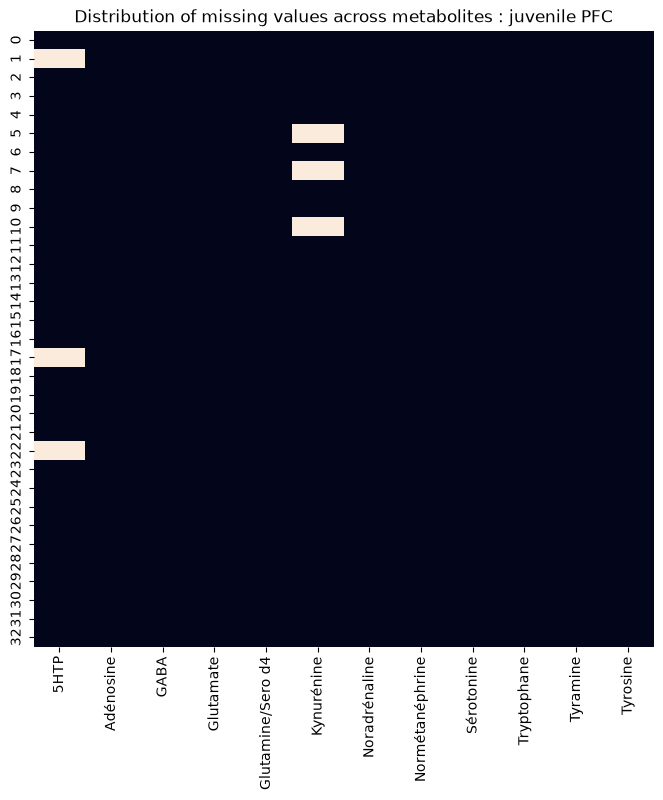

In [14]:
plt.figure(figsize=(8, 8))
sns.heatmap(X_juv_pfc.isna(), cbar=False)
plt.title("Distribution of missing values across metabolites : juvenile PFC")
plt.show()

In [15]:
print("Information about the Individuals who have missing values : PFC juv")
print(X_juv_pfc[X_juv_pfc.isna().any(axis=1)].to_markdown())


Information about the Individuals who have missing values : PFC juv
|    |      5HTP |   Adénosine |   GABA |   Glutamate |   Glutamine/Sero d4 |   Kynurénine |   Noradrénaline |   Normétanéphrine |   Sérotonine |   Tryptophane |   Tyramine |   Tyrosine |
|---:|----------:|------------:|-------:|------------:|--------------------:|-------------:|----------------:|------------------:|-------------:|--------------:|-----------:|-----------:|
|  1 | nan       |     0.114   |  4.946 |       3.372 |              353.2  |    0.000348  |          0.4457 |            1.248  |      0.2482  |        1.621  |    0.02929 |      9.92  |
|  5 |   0.07679 |     0.06489 |  4.35  |       3.066 |               26.69 |  nan         |          0.4418 |            0.866  |      0.2674  |        0.7045 |    0.08121 |      5.788 |
|  7 |   0.05436 |     0.04628 |  2.341 |       1.479 |               14.08 |  nan         |          0.2165 |            0.4885 |      0.09258 |        0.448  |    0.0355  |      

In [16]:
X_juv_pfc = X_juv_pfc.dropna()
Y_juv_pfc = Y_juv_pfc.loc[X_juv_pfc.index]

In [17]:
X_juv_pfc_with_group = X_juv_pfc.copy()
X_juv_pfc_with_group["Group"] = Y_juv_pfc.map({0: "CONT", 1: "LBN"})
X_juv_pfc_with_group.head()

,5HTP,Adénosine,GABA,Glutamate,Glutamine/Sero d4,Kynurénine,Noradrénaline,Normétanéphrine,Sérotonine,Tryptophane,Tyramine,Tyrosine,Group
0,0.07121,0.1205,5.705,5.624,115.70,0.000358,0.5434,1.1470,0.1690,17.2300,0.12430,72.290,LBN
2,0.09554,0.2878,4.199,3.240,61.33,0.000197,0.4152,0.7497,0.2027,0.6687,0.02476,5.434,LBN
3,0.07400,0.1642,4.777,3.392,83.70,0.000197,0.3339,1.3270,0.1919,0.8614,0.08478,5.847,LBN
4,0.06886,0.1563,4.204,3.150,81.44,0.000172,0.4195,0.7535,0.1023,0.9502,0.02396,6.285,LBN
6,0.06273,0.1830,5.295,3.482,104.60,0.000221,0.3053,1.2960,0.1708,1.0410,0.17380,8.075,LBN


---

#### For the HIP

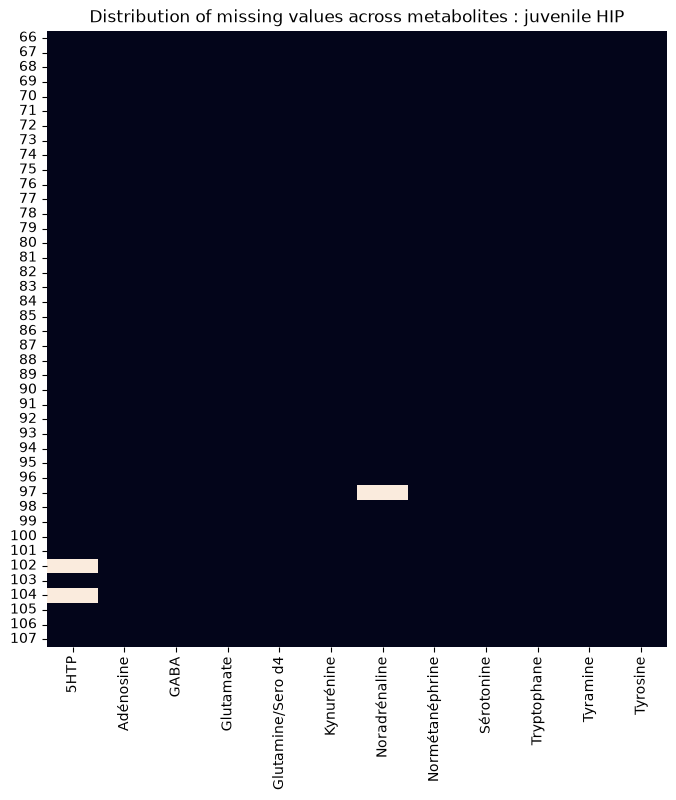

In [18]:
plt.figure(figsize=(8, 8))
sns.heatmap(X_juv_hip.isna(), cbar=False)
plt.title("Distribution of missing values across metabolites : juvenile HIP")
plt.show()

In [19]:
print("Information about the Individuals who have missing values : HIP juv")
print(X_juv_hip[X_juv_hip.isna().any(axis=1)].to_markdown())


Information about the Individuals who have missing values : HIP juv
|     |      5HTP |   Adénosine |   GABA |   Glutamate |   Glutamine/Sero d4 |   Kynurénine |   Noradrénaline |   Normétanéphrine |   Sérotonine |   Tryptophane |   Tyramine |   Tyrosine |
|----:|----------:|------------:|-------:|------------:|--------------------:|-------------:|----------------:|------------------:|-------------:|--------------:|-----------:|-----------:|
|  97 |   0.03652 |      0.1513 |  4.149 |       2.817 |              209.8  |    0.0003631 |        nan      |            0.9053 |       0.1095 |        3.502  |     0.2702 |     17.31  |
| 102 | nan       |      0.3103 |  4.02  |       2.682 |               84.33 |    0.0003547 |          0.312  |            0.7644 |       0.2293 |        0.7045 |     0.3007 |      5.821 |
| 104 | nan       |      0.1994 |  3.526 |       2.275 |               91.51 |    0.0002266 |          0.2811 |            0.6544 |       0.2525 |        5.527  |     0.2244 | 

In [20]:
X_juv_hip = X_juv_hip.dropna()
Y_juv_hip = Y_juv_hip.loc[X_juv_hip.index]

In [21]:
X_juv_hip_with_group = X_juv_hip.copy()
X_juv_hip_with_group["Group"] = Y_juv_hip.map({0: "CONT", 1: "LBN"})
X_juv_hip_with_group.head()

,5HTP,Adénosine,GABA,Glutamate,Glutamine/Sero d4,Kynurénine,Noradrénaline,Normétanéphrine,Sérotonine,Tryptophane,Tyramine,Tyrosine,Group
66,0.16110,0.1061,5.316,3.774,459.1,0.000304,0.5380,0.6292,0.3534,2.560,0.05877,10.990,LBN
67,0.04372,0.1037,5.288,3.645,111.6,0.000386,0.5103,0.8059,0.2138,1.354,0.02393,7.273,LBN
68,0.17180,0.2305,6.150,4.494,507.8,0.000291,0.5944,0.8248,0.4750,1.920,0.02132,9.272,LBN
69,0.14740,0.2582,6.843,5.044,571.3,0.000312,0.5672,1.0550,0.4088,7.368,0.02837,18.700,LBN
70,0.15700,0.2091,5.723,4.118,380.8,0.000209,0.5549,0.5001,0.4062,3.666,0.02336,15.970,LBN


---

#### For the STR

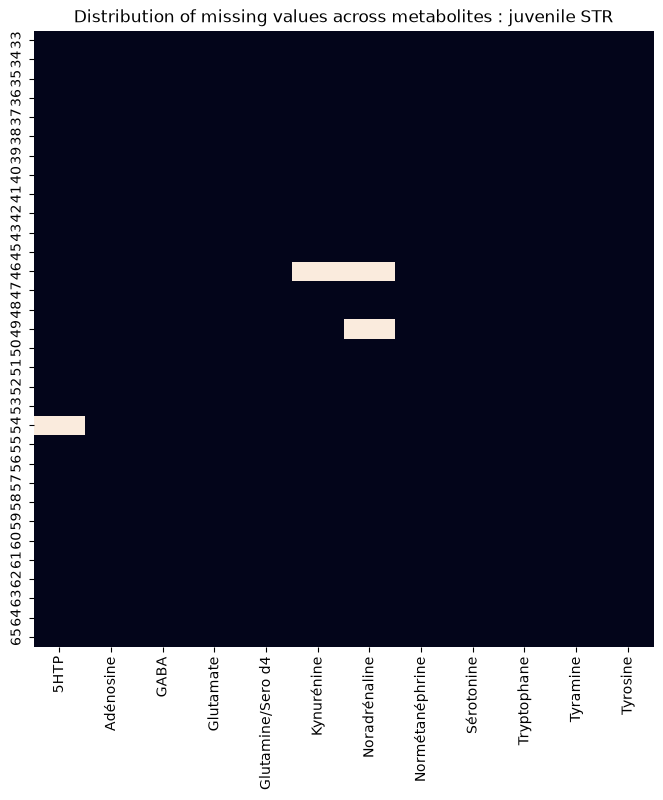

In [22]:
plt.figure(figsize=(8, 8))
sns.heatmap(X_juv_str.isna(), cbar=False)
plt.title("Distribution of missing values across metabolites : juvenile STR")
plt.show()

In [23]:
print("Information about the Individuals who have missing values : STR juv")
print(X_juv_str[X_juv_str.isna().any(axis=1)].to_markdown())

Information about the Individuals who have missing values : STR juv
|    |      5HTP |   Adénosine |   GABA |   Glutamate |   Glutamine/Sero d4 |   Kynurénine |   Noradrénaline |   Normétanéphrine |   Sérotonine |   Tryptophane |   Tyramine |   Tyrosine |
|---:|----------:|------------:|-------:|------------:|--------------------:|-------------:|----------------:|------------------:|-------------:|--------------:|-----------:|-----------:|
| 46 |   0.05638 |      0.6234 |  3.645 |       2.412 |               37.69 |  nan         |       nan       |            0.2305 |       0.2553 |         1.509 |    0.1939  |      5.732 |
| 49 |   0.04216 |      0.5245 |  3.43  |       2.452 |               38.49 |    9.549e-05 |       nan       |            0.2024 |       0.134  |         1.583 |    0.09083 |      7.25  |
| 54 | nan       |      2.587  |  7.975 |       3.185 |              164.7  |    0.0002746 |         0.09882 |            0.3882 |       0.2074 |         2.63  |    0.2646  |      

In [24]:
X_juv_str = X_juv_str.dropna()
Y_juv_str = Y_juv_str.loc[X_juv_str.index]

In [25]:
X_juv_str_with_group = X_juv_str.copy()
X_juv_str_with_group["Group"] = Y_juv_str.map({0: "CONT", 1: "LBN"})
X_juv_str_with_group.head()

,5HTP,Adénosine,GABA,Glutamate,Glutamine/Sero d4,Kynurénine,Noradrénaline,Normétanéphrine,Sérotonine,Tryptophane,Tyramine,Tyrosine,Group
33,0.15510,0.4607,8.217,4.325,217.10,0.000358,0.7035,0.3851,0.2305,1.3440,0.18670,9.593,LBN
34,0.12050,0.6893,4.277,4.705,510.40,0.000413,0.1120,0.2321,0.1860,3.7550,0.17590,28.770,LBN
35,0.13190,0.7967,8.135,3.710,82.61,0.000305,0.8191,0.3697,0.6090,0.8823,0.10010,7.236,LBN
36,0.28870,0.7879,8.587,3.302,525.90,0.000302,0.6250,0.4807,0.3300,1.3680,0.08390,9.025,LBN
37,0.08625,0.4957,6.949,3.710,71.17,0.000232,0.7227,0.3707,0.4726,1.0300,0.08277,8.320,LBN


#### Transformation Log 

In [26]:
X_juv_pfc_log = np.log1p(X_juv_pfc)
X_juv_hip_log = np.log1p(X_juv_hip)
X_juv_str_log = np.log1p(X_juv_str)

## Analysis

### Hierarchical clustering

---

#### For the PFC

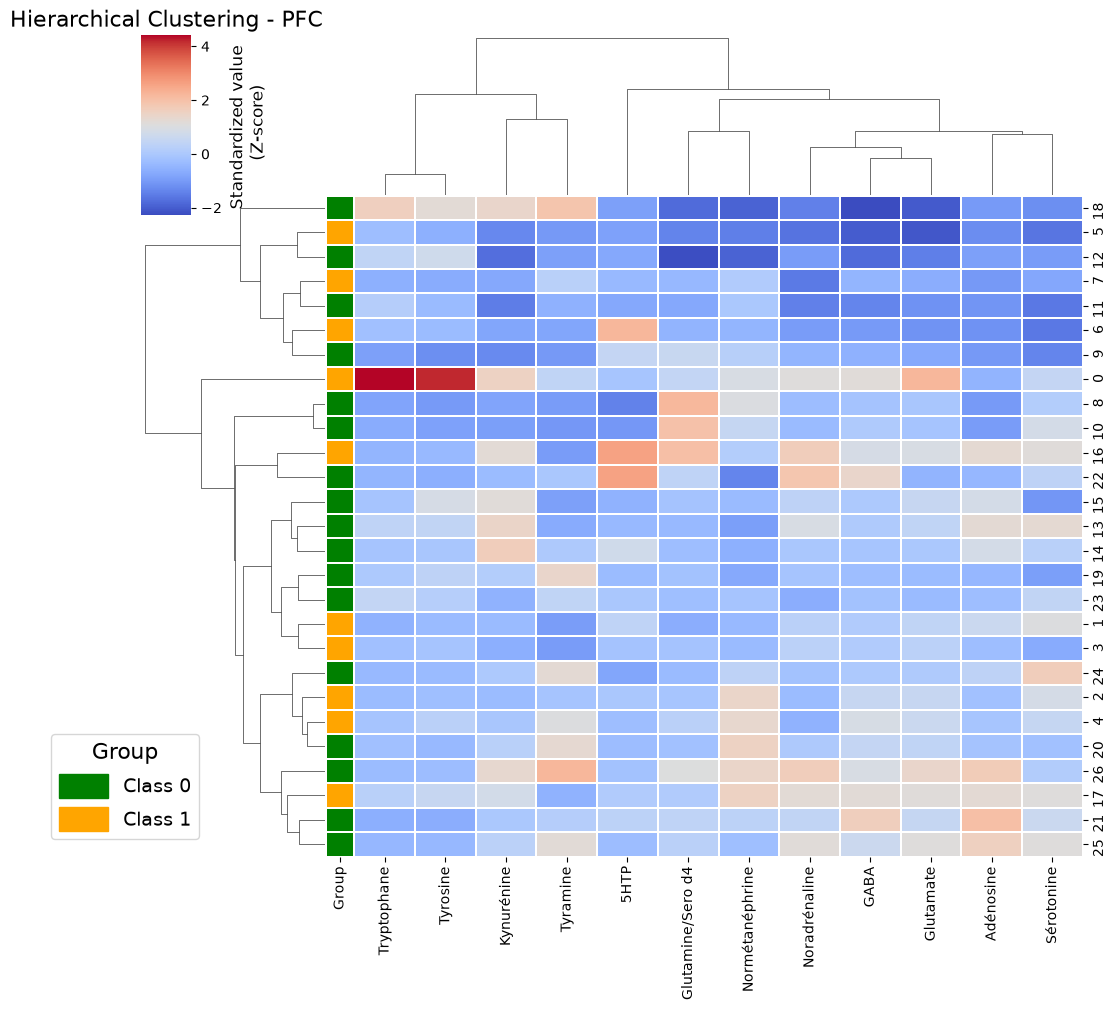

In [27]:
import matplotlib.patches as mpatches

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_juv_pfc_log)

row_colors = Y_juv_pfc.reset_index(drop=True).map({
    0: "green",
    1: "orange"
})

g = sns.clustermap(
    pd.DataFrame(
        X_scaled,
        columns=X_juv_pfc_log.columns
    ),
    method="ward",
    metric="euclidean",
    cmap="coolwarm",
    row_colors=row_colors,
    linewidths=0.2,
    figsize=(10,10)
)

legend_handles = [
    mpatches.Patch(color="green", label="Class 0"),
    mpatches.Patch(color="orange", label="Class 1")
]

g.ax_heatmap.legend(
    handles=legend_handles,
    title="Group",
    loc="upper right",
    bbox_to_anchor=(-0.2, 0.2),
    fontsize=14,        
    title_fontsize=16,  
    handlelength=2.5,  
    handleheight=1.5    
)
g.cax.set_ylabel("Standardized value \n (Z-score)", fontsize=12)
plt.title("Hierarchical Clustering - PFC", fontsize=16)
plt.show()

In [28]:
from scipy.cluster.hierarchy import linkage, fcluster

Z = linkage(
    X_scaled,
    method="ward",
    metric="euclidean"
)

clusters = fcluster(
    Z,
    t=2,
    criterion="maxclust"
)

cluster_df = pd.DataFrame({
    "Group": Y_juv_pfc.reset_index(drop=True),
    "Cluster": clusters
})

ct = pd.crosstab(
    cluster_df["Cluster"],
    cluster_df["Group"],
    margins = True
)

ct.columns = ["Class 0", "Class 1", "Total"]
ct.index.name = "Cluster"
print(ct)

         Class 0  Class 1  Total
Cluster                         
1              4        3      7
2             13        7     20
All           17       10     27


---

#### For the HIP

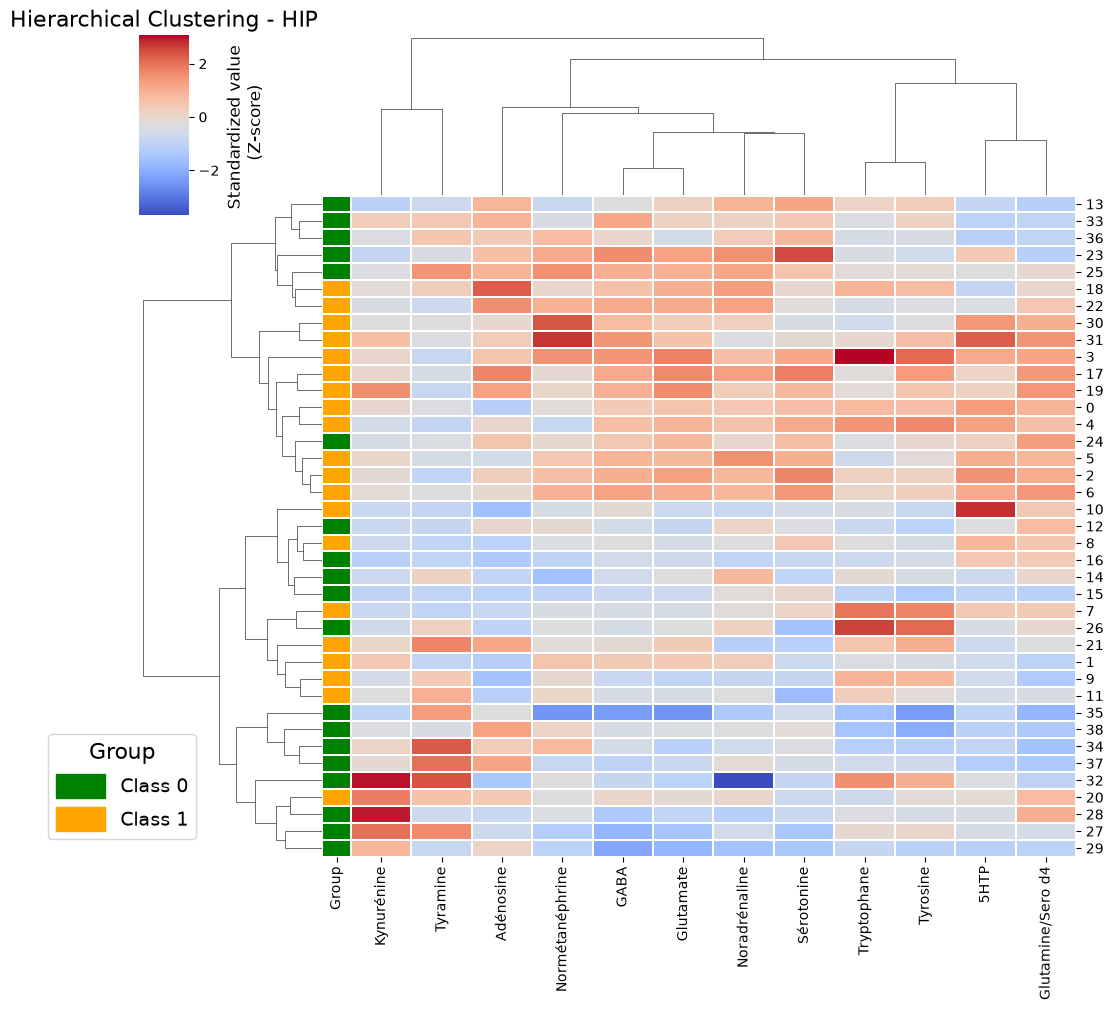

In [29]:
import matplotlib.patches as mpatches

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_juv_hip_log)

row_colors = Y_juv_hip.reset_index(drop=True).map({
    0: "green",
    1: "orange"
})

g = sns.clustermap(
    pd.DataFrame(
        X_scaled,
        columns=X_juv_hip_log.columns
    ),
    method="ward",
    metric="euclidean",
    cmap="coolwarm",
    row_colors=row_colors,
    linewidths=0.2,
    figsize=(10,10)
)

legend_handles = [
    mpatches.Patch(color="green", label="Class 0"),
    mpatches.Patch(color="orange", label="Class 1")
]

g.ax_heatmap.legend(
    handles=legend_handles,
    title="Group",
    loc="upper right",
    bbox_to_anchor=(-0.2, 0.2),
    fontsize=14,        
    title_fontsize=16,  
    handlelength=2.5,  
    handleheight=1.5    
)
g.cax.set_ylabel("Standardized value \n (Z-score)", fontsize=12)
plt.title("Hierarchical Clustering - HIP", fontsize=16)
plt.show()

In [30]:
from scipy.cluster.hierarchy import linkage, fcluster

Z = linkage(
    X_scaled,
    method="ward",
    metric="euclidean"
)

clusters = fcluster(
    Z,
    t=2,
    criterion="maxclust"
)

cluster_df = pd.DataFrame({
    "Group": Y_juv_hip.reset_index(drop=True),
    "Cluster": clusters
})

ct = pd.crosstab(
    cluster_df["Cluster"],
    cluster_df["Group"],
    margins = True
)

ct.columns = ["Class 0", "Class 1", "Total"]
ct.index.name = "Cluster"
print(ct)

         Class 0  Class 1  Total
Cluster                         
1              6       12     18
2             13        8     21
All           19       20     39


In [31]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)
print(score)

0.22439739128002004


---

#### For the STR

In [32]:
X_juv_str_log2 = X_juv_str_log.drop(X_juv_str_log.index[19])
Y_juv_str2 = Y_juv_str.drop(Y_juv_str.index[19])

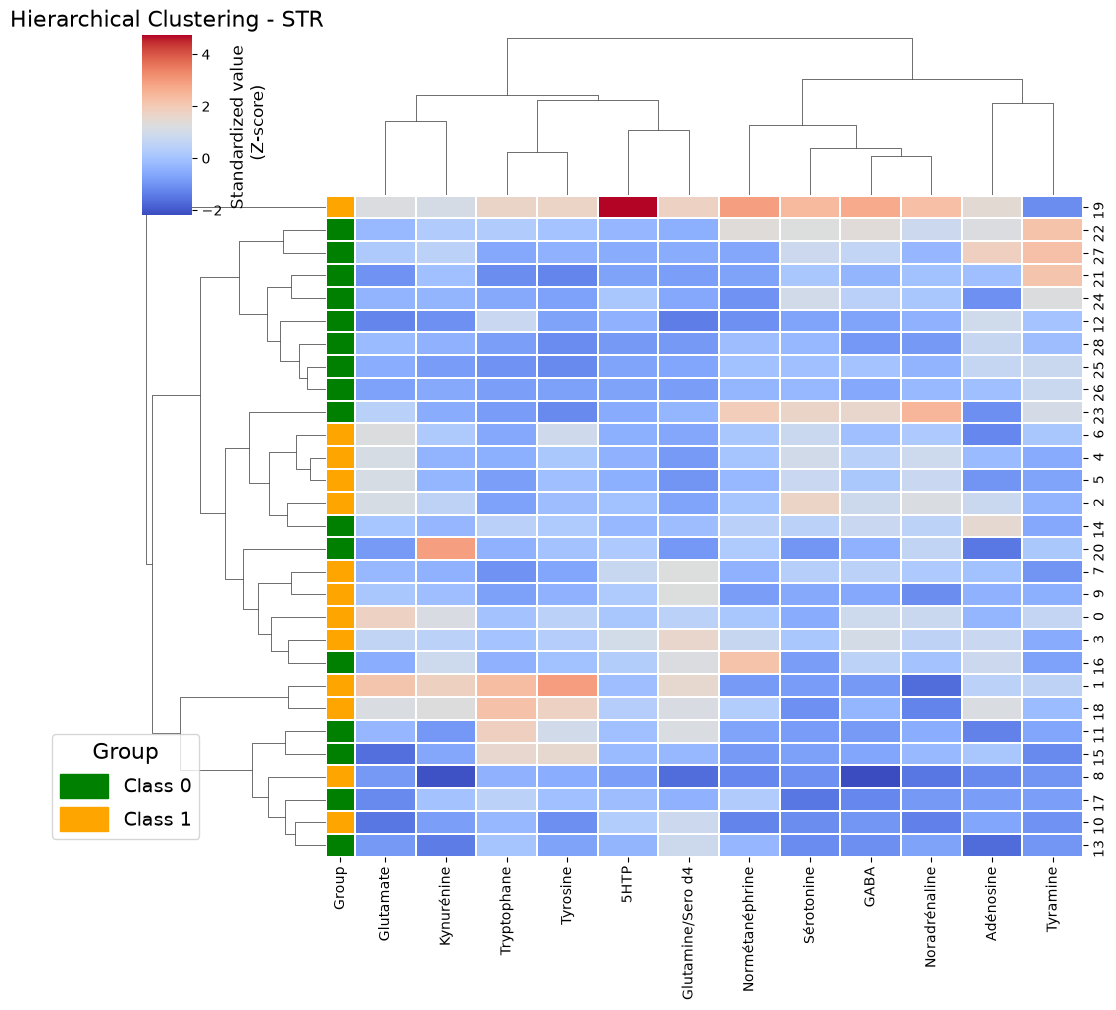

In [33]:
import matplotlib.patches as mpatches


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_juv_str_log)

row_colors = Y_juv_str.reset_index(drop=True).map({
    0: "green",
    1: "orange"
})

g = sns.clustermap(
    pd.DataFrame(
        X_scaled,
        columns=X_juv_str_log.columns
    ),
    method="ward",
    metric="euclidean",
    cmap="coolwarm",
    row_colors=row_colors,
    linewidths=0.2,
    figsize=(10,10)
)

legend_handles = [
    mpatches.Patch(color="green", label="Class 0"),
    mpatches.Patch(color="orange", label="Class 1")
]

g.ax_heatmap.legend(
    handles=legend_handles,
    title="Group",
    loc="upper right",
    bbox_to_anchor=(-0.2, 0.2),
    fontsize=14,        
    title_fontsize=16,  
    handlelength=2.5,  
    handleheight=1.5    
)
g.cax.set_ylabel("Standardized value \n (Z-score)", fontsize=12)
plt.title("Hierarchical Clustering - STR", fontsize=16)
plt.show()

In [34]:
from scipy.cluster.hierarchy import linkage, fcluster

Z = linkage(
    X_scaled,
    method="ward",
    metric="euclidean"
)

clusters = fcluster(
    Z,
    t=2,
    criterion="maxclust"
)

cluster_df = pd.DataFrame({
    "Group": Y_juv_str.reset_index(drop=True),
    "Cluster": clusters
})

ct = pd.crosstab(
    cluster_df["Cluster"],
    cluster_df["Group"],
    margins = True
)

ct.columns = ["Class 0", "Class 1", "Total"]
ct.index.name = "Cluster"
print(ct)

         Class 0  Class 1  Total
Cluster                         
1             16       12     28
2              0        1      1
All           16       13     29


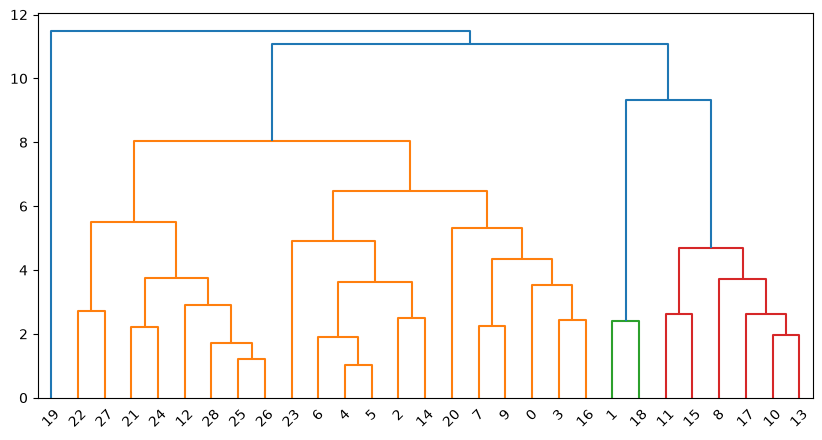

In [35]:
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
dendrogram(Z)
plt.show()

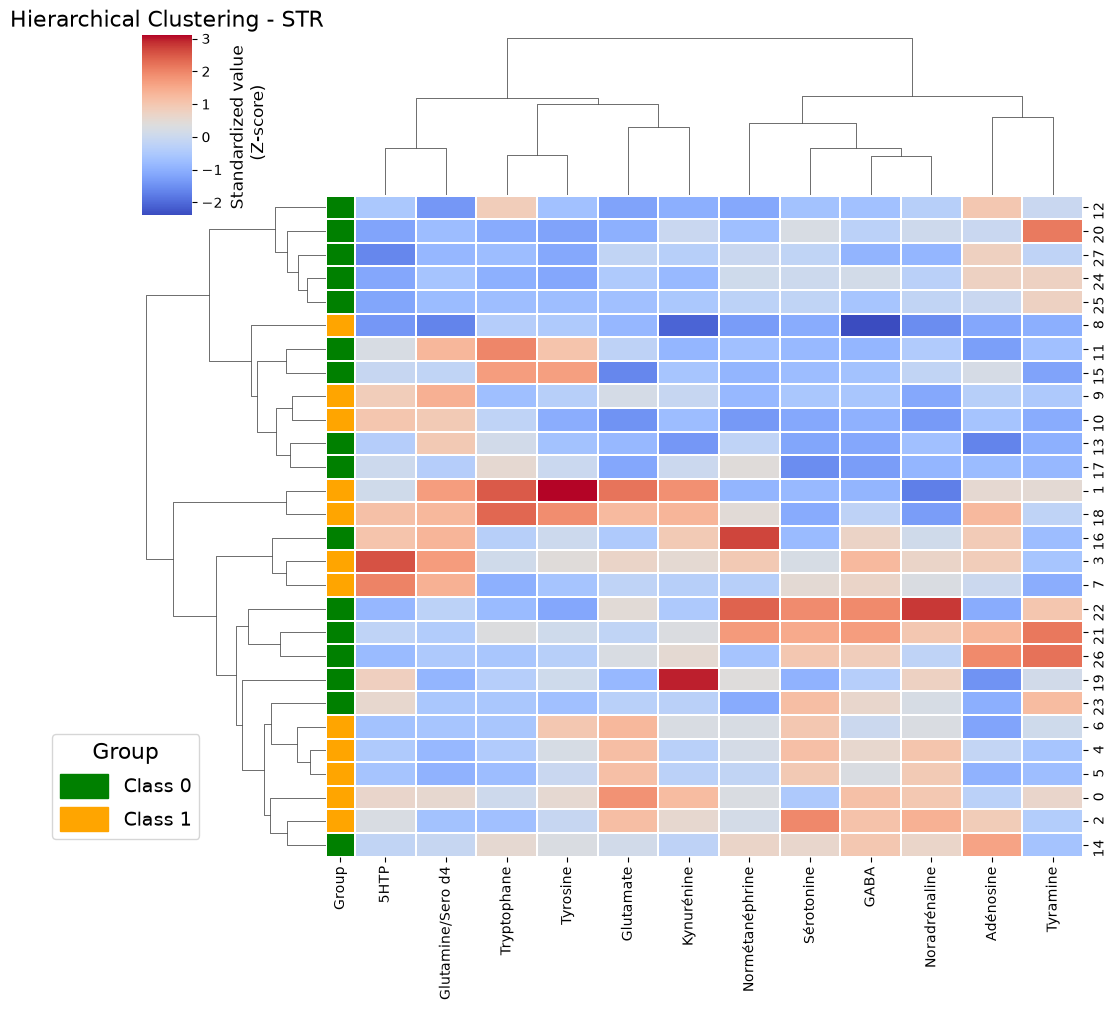

In [36]:
import matplotlib.patches as mpatches


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_juv_str_log2)

row_colors = Y_juv_str2.reset_index(drop=True).map({
    0: "green",
    1: "orange"
})

g = sns.clustermap(
    pd.DataFrame(
        X_scaled,
        columns=X_juv_str_log2.columns
    ),
    method="ward",
    metric="euclidean",
    cmap="coolwarm",
    row_colors=row_colors,
    linewidths=0.2,
    figsize=(10,10)
)

legend_handles = [
    mpatches.Patch(color="green", label="Class 0"),
    mpatches.Patch(color="orange", label="Class 1")
]

g.ax_heatmap.legend(
    handles=legend_handles,
    title="Group",
    loc="upper right",
    bbox_to_anchor=(-0.2, 0.2),
    fontsize=14,        
    title_fontsize=16,  
    handlelength=2.5,  
    handleheight=1.5    
)
g.cax.set_ylabel("Standardized value \n (Z-score)", fontsize=12)
plt.title("Hierarchical Clustering - STR", fontsize=16)
plt.show()

In [37]:
from scipy.cluster.hierarchy import linkage, fcluster

Z = linkage(
    X_scaled,
    method="ward",
    metric="euclidean"
)

clusters = fcluster(
    Z,
    t=2,
    criterion="maxclust"
)

cluster_df = pd.DataFrame({
    "Group": Y_juv_str2.reset_index(drop=True),
    "Cluster": clusters
})

ct = pd.crosstab(
    cluster_df["Cluster"],
    cluster_df["Group"],
    margins = True
)

ct.columns = ["Class 0", "Class 1", "Total"]
ct.index.name = "Cluster"
print(ct)

         Class 0  Class 1  Total
Cluster                         
1              9        3     12
2              7        9     16
All           16       12     28


### Logistic Regression

--- 

#### For the PFC

In [38]:
log_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        C=1,
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

log_scores_pfc = cross_val_score(
    log_pipe,
    X_juv_pfc_log,
    Y_juv_pfc,
    cv=cv,
    scoring="roc_auc"
)

c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\U

In [39]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, recall_score

# Sensitivity = Recall of positive class (LBN = 1)
sensitivity = make_scorer(
    recall_score,
    pos_label=1
)

# Specificity = Recall of negative class (CONT = 0)
specificity = make_scorer(
    recall_score,
    pos_label=0
)

scores = cross_validate(
    log_pipe,
    X_juv_pfc_log,
    Y_juv_pfc,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "auc": "roc_auc",
        "sensitivity": sensitivity,
        "specificity": specificity
    },
    n_jobs=-1
)

print("===== Logistic Regression =====")

print(f"Accuracy    = {scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}")

print(f"Sensitivity = {scores['test_sensitivity'].mean():.3f} ± {scores['test_sensitivity'].std():.3f}")

print(f"Specificity = {scores['test_specificity'].mean():.3f} ± {scores['test_specificity'].std():.3f}")

print(f"AUC         = {scores['test_auc'].mean():.3f} ± {scores['test_auc'].std():.3f}")

===== Logistic Regression =====
Accuracy    = 0.521 ± 0.150
Sensitivity = 0.480 ± 0.316
Specificity = 0.545 ± 0.203
AUC         = 0.546 ± 0.223


c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\U

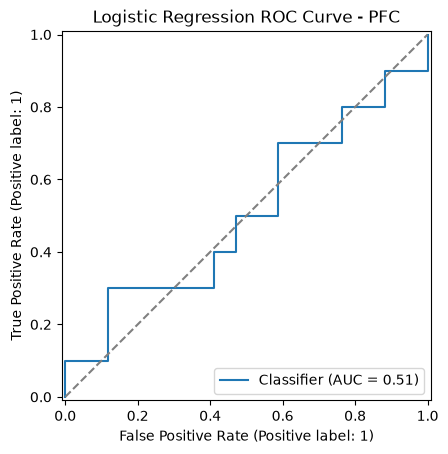

In [40]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

cv_roc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    log_pipe,
    X_juv_pfc_log,
    Y_juv_pfc,
    cv=cv_roc,
    method="predict_proba"
)[:,1]

RocCurveDisplay.from_predictions(
    Y_juv_pfc,
    y_prob
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="grey",
    label="Random classifier"
)

plt.title("Logistic Regression ROC Curve - PFC")
plt.show()

In [41]:
log_pipe.fit(X_juv_pfc_log, Y_juv_pfc)

coef = pd.DataFrame({
    "NT": X_juv_pfc_log.columns,
    "Coefficient":
        log_pipe.named_steps["logreg"].coef_[0]
})
coef = coef.sort_values(by="Coefficient", ascending=False)

print(coef)

                   NT  Coefficient
0                5HTP     0.869208
7     Normétanéphrine     0.703314
3           Glutamate     0.646008
11           Tyrosine     0.365235
8          Sérotonine     0.180667
2                GABA     0.113143
9         Tryptophane     0.048485
5          Kynurénine    -0.097811
1           Adénosine    -0.377644
4   Glutamine/Sero d4    -0.601036
6       Noradrénaline    -0.697403
10           Tyramine    -0.894097


c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


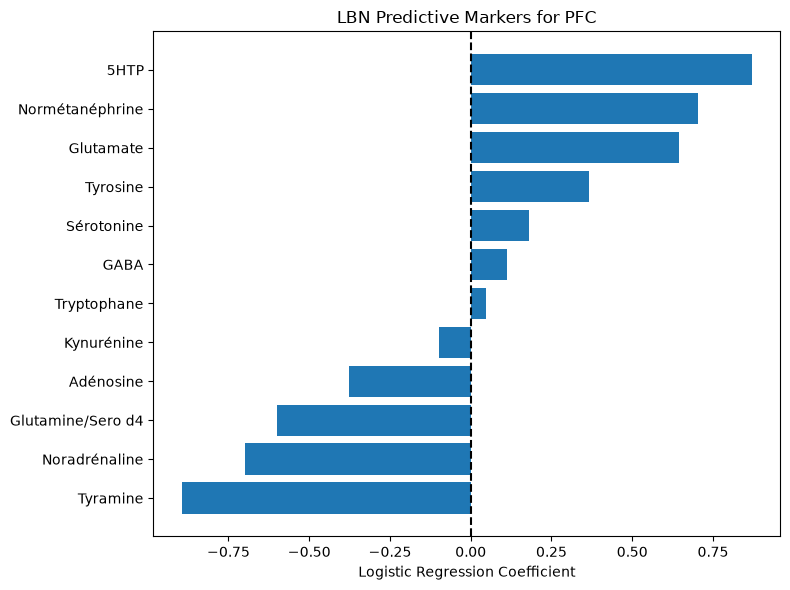

In [42]:
import matplotlib.pyplot as plt

coef = coef.sort_values("Coefficient")

plt.figure(figsize=(8,6))

plt.barh(
    coef["NT"],
    coef["Coefficient"]
)

plt.axvline(
    0,
    color="black",
    linestyle="--"
)

plt.xlabel("Logistic Regression Coefficient")
plt.title("LBN Predictive Markers for PFC")

plt.tight_layout()
plt.show()

In [43]:
import numpy as np
import pandas as pd

from sklearn.utils import resample

n_boot = 1000

coef_boot = pd.DataFrame(
    columns=X_juv_pfc_log.columns
)

for i in range(n_boot):

    # Bootstrap sample
    X_boot, Y_boot = resample(
        X_juv_pfc_log,
        Y_juv_pfc,
        replace=True,
        random_state=i
    )

    # Fit pipeline
    log_pipe.fit(X_boot, Y_boot)

    # Save coefficients
    coef_boot.loc[i] = log_pipe.named_steps["logreg"].coef_[0]

c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\U

In [44]:
summary = pd.DataFrame({
    "Mean": coef_boot.mean(),
    "Lower95": coef_boot.quantile(0.025),
    "Upper95": coef_boot.quantile(0.975)
})

summary

,Mean,Lower95,Upper95
5HTP,0.779068,-0.102594,1.492256
Adénosine,-0.386039,-0.985282,0.322885
GABA,0.203986,-0.483871,0.876194
Glutamate,0.567823,-0.069105,1.276110
Glutamine/Sero d4,-0.581980,-1.288262,0.213495
Kynurénine,-0.165020,-0.877078,0.658770
Noradrénaline,-0.550400,-1.235880,0.265979
Normétanéphrine,0.614414,-0.222335,1.289127
Sérotonine,0.149421,-0.638860,0.886184
Tryptophane,-0.031290,-0.870726,0.521885


---

#### For the HIP

In [45]:
log_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        C=1,
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

log_scores_hip = cross_val_score(
    log_pipe,
    X_juv_hip_log,
    Y_juv_hip,
    cv=cv,
    scoring="roc_auc"
)

c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\U

c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\U

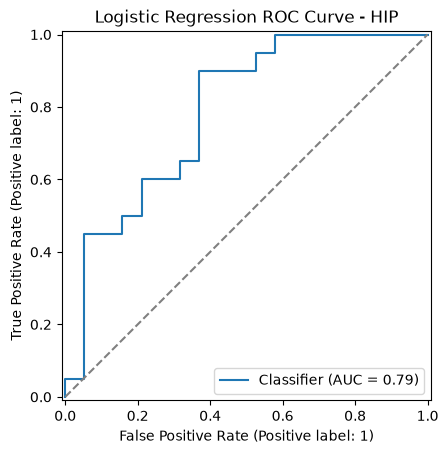

In [46]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

cv_roc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    log_pipe,
    X_juv_hip_log,
    Y_juv_hip,
    cv=cv_roc,
    method="predict_proba"
)[:,1]

RocCurveDisplay.from_predictions(
    Y_juv_hip,
    y_prob
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="grey",
    label="Random classifier"
)

plt.title("Logistic Regression ROC Curve - HIP")
plt.show()

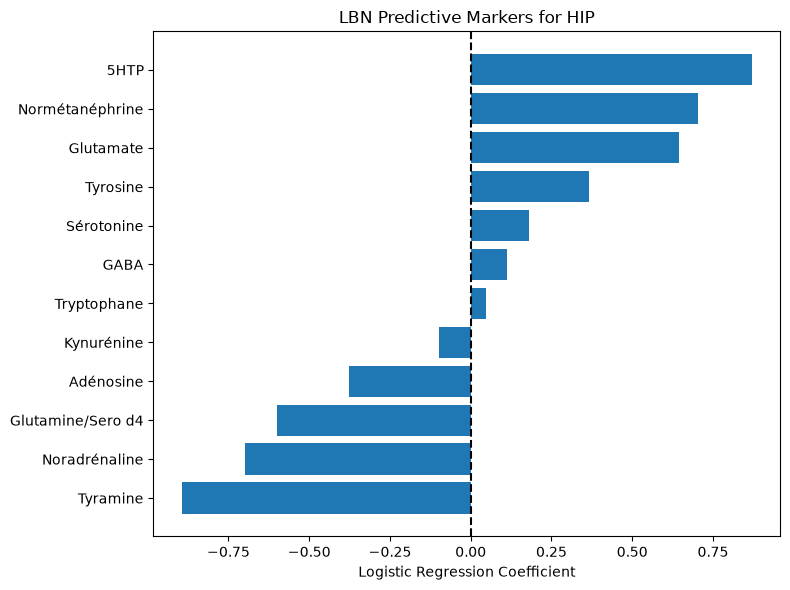

In [47]:
import matplotlib.pyplot as plt

coef = coef.sort_values("Coefficient")

plt.figure(figsize=(8,6))

plt.barh(
    coef["NT"],
    coef["Coefficient"]
)

plt.axvline(
    0,
    color="black",
    linestyle="--"
)

plt.xlabel("Logistic Regression Coefficient")
plt.title("LBN Predictive Markers for HIP")

plt.tight_layout()
plt.show()

In [48]:
import numpy as np
import pandas as pd

from sklearn.utils import resample

n_boot = 1000

coef_boot = pd.DataFrame(
    columns=X_juv_hip_log.columns
)

for i in range(n_boot):

    # Bootstrap sample
    X_boot, Y_boot = resample(
        X_juv_hip_log,
        Y_juv_hip,
        replace=True,
        random_state=i
    )

    # Fit pipeline
    log_pipe.fit(X_boot, Y_boot)

    # Save coefficients
    coef_boot.loc[i] = log_pipe.named_steps["logreg"].coef_[0]

c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\U

In [49]:
summary = pd.DataFrame({
    "Mean": coef_boot.mean(),
    "Lower95": coef_boot.quantile(0.025),
    "Upper95": coef_boot.quantile(0.975)
})

summary

,Mean,Lower95,Upper95
5HTP,0.961664,0.387362,1.484305
Adénosine,-0.144575,-0.866453,0.590081
GABA,0.544575,0.019214,1.012894
Glutamate,0.563650,-0.055002,1.187411
Glutamine/Sero d4,0.301034,-0.521832,1.099941
Kynurénine,0.200421,-0.555605,1.062300
Noradrénaline,0.137184,-0.824134,1.011461
Normétanéphrine,0.424738,-0.273222,1.110886
Sérotonine,-0.712867,-1.462317,0.233765
Tryptophane,0.259069,-0.543360,1.127570


---

#### For the STR

In [50]:
log_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        C=1,
        max_iter=5000,
        random_state=42
    ))
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

log_scores_str = cross_val_score(
    log_pipe,
    X_juv_str_log,
    Y_juv_str,
    cv=cv,
    scoring="roc_auc"
)


c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\U

In [51]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, recall_score

# Sensitivity = Recall of positive class (LBN = 1)
sensitivity = make_scorer(
    recall_score,
    pos_label=1
)

# Specificity = Recall of negative class (CONT = 0)
specificity = make_scorer(
    recall_score,
    pos_label=0
)

scores = cross_validate(
    log_pipe,
    X_juv_str_log,
    Y_juv_str,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "auc": "roc_auc",
        "sensitivity": sensitivity,
        "specificity": specificity
    },
    n_jobs=-1
)

print("===== Logistic Regression =====")

print(f"Accuracy    = {scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}")

print(f"Sensitivity = {scores['test_sensitivity'].mean():.3f} ± {scores['test_sensitivity'].std():.3f}")

print(f"Specificity = {scores['test_specificity'].mean():.3f} ± {scores['test_specificity'].std():.3f}")

print(f"AUC         = {scores['test_auc'].mean():.3f} ± {scores['test_auc'].std():.3f}")

===== Logistic Regression =====
Accuracy    = 0.851 ± 0.147
Sensitivity = 0.828 ± 0.228
Specificity = 0.869 ± 0.201
AUC         = 0.902 ± 0.155


c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\U

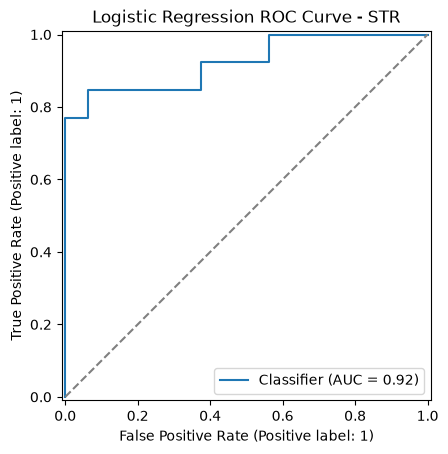

In [52]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

cv_roc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    log_pipe,
    X_juv_str_log,
    Y_juv_str,
    cv=cv_roc,
    method="predict_proba"
)[:,1]

RocCurveDisplay.from_predictions(
    Y_juv_str,
    y_prob
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="grey",
    label="Random classifier"
)

plt.title("Logistic Regression ROC Curve - STR")
plt.show()

In [53]:
log_pipe.fit(X_juv_str_log, Y_juv_str)

coef = pd.DataFrame({
    "NT": X_juv_str_log.columns,
    "Coefficient":
        log_pipe.named_steps["logreg"].coef_[0]
})
coef = coef.sort_values(by="Coefficient", ascending=False)

print(coef)

                   NT  Coefficient
3           Glutamate     1.558971
0                5HTP     0.831779
11           Tyrosine     0.346551
8          Sérotonine     0.196718
4   Glutamine/Sero d4     0.178263
5          Kynurénine     0.058762
1           Adénosine    -0.102894
2                GABA    -0.123741
6       Noradrénaline    -0.424804
9         Tryptophane    -0.736695
7     Normétanéphrine    -0.757327
10           Tyramine    -1.037677


c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


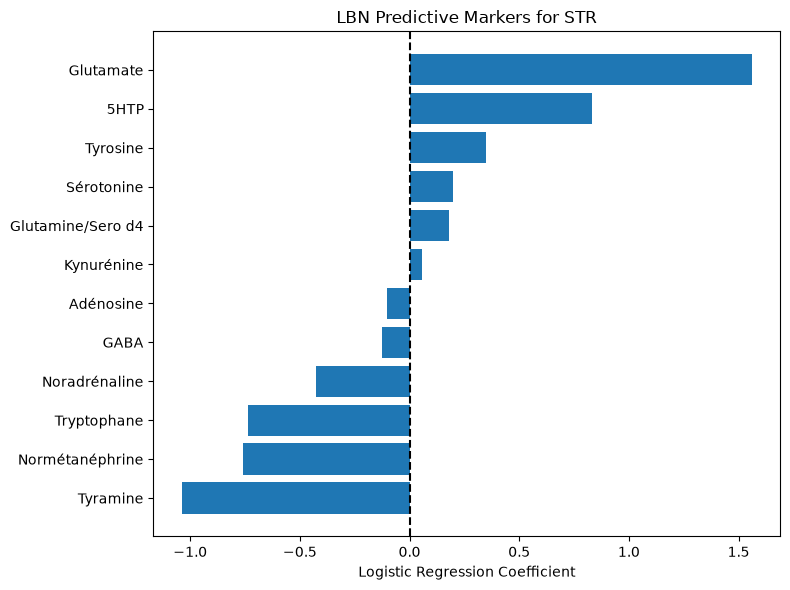

In [54]:
import matplotlib.pyplot as plt

coef = coef.sort_values("Coefficient")

plt.figure(figsize=(8,6))

plt.barh(
    coef["NT"],
    coef["Coefficient"]
)

plt.axvline(
    0,
    color="black",
    linestyle="--"
)

plt.xlabel("Logistic Regression Coefficient")
plt.title("LBN Predictive Markers for STR")

plt.tight_layout()
plt.show()

In [55]:
import numpy as np
import pandas as pd

from sklearn.utils import resample

n_boot = 1000

coef_boot = pd.DataFrame(
    columns=X_juv_str_log.columns
)

for i in range(n_boot):

    # Bootstrap sample
    X_boot, Y_boot = resample(
        X_juv_str_log,
        Y_juv_str,
        replace=True,
        random_state=i
    )

    # Fit pipeline
    log_pipe.fit(X_boot, Y_boot)

    # Save coefficients
    coef_boot.loc[i] = log_pipe.named_steps["logreg"].coef_[0]

c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\U

In [56]:
summary = pd.DataFrame({
    "Mean": coef_boot.mean(),
    "Lower95": coef_boot.quantile(0.025),
    "Upper95": coef_boot.quantile(0.975)
})

summary

,Mean,Lower95,Upper95
5HTP,0.716265,0.273656,1.132365
Adénosine,-0.172652,-0.784442,0.386480
GABA,-0.100988,-0.498831,0.368760
Glutamate,1.430196,0.899802,1.858978
Glutamine/Sero d4,0.222743,-0.495499,0.952757
Kynurénine,0.063243,-0.546363,0.781989
Noradrénaline,-0.301954,-0.749693,0.174553
Normétanéphrine,-0.645876,-1.165497,-0.003622
Sérotonine,0.262706,-0.208651,0.685043
Tryptophane,-0.605500,-1.121539,-0.031284


---
Without row 19

In [57]:
log_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        C=1,
        max_iter=5000,
        random_state=42
    ))
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

log_scores_str = cross_val_score(
    log_pipe,
    X_juv_str_log2,
    Y_juv_str2,
    cv=cv,
    scoring="roc_auc"
)


c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\U

In [58]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, recall_score

# Sensitivity = Recall of positive class (LBN = 1)
sensitivity = make_scorer(
    recall_score,
    pos_label=1
)

# Specificity = Recall of negative class (CONT = 0)
specificity = make_scorer(
    recall_score,
    pos_label=0
)

scores = cross_validate(
    log_pipe,
    X_juv_str_log2,
    Y_juv_str2,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "auc": "roc_auc",
        "sensitivity": sensitivity,
        "specificity": specificity
    },
    n_jobs=-1
)

print("===== Logistic Regression =====")

print(f"Accuracy    = {scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}")

print(f"Sensitivity = {scores['test_sensitivity'].mean():.3f} ± {scores['test_sensitivity'].std():.3f}")

print(f"Specificity = {scores['test_specificity'].mean():.3f} ± {scores['test_specificity'].std():.3f}")

print(f"AUC         = {scores['test_auc'].mean():.3f} ± {scores['test_auc'].std():.3f}")

===== Logistic Regression =====
Accuracy    = 0.825 ± 0.159
Sensitivity = 0.805 ± 0.254
Specificity = 0.839 ± 0.221
AUC         = 0.914 ± 0.153


c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\U

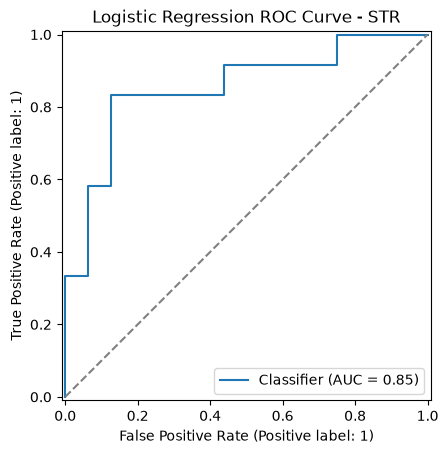

In [59]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

cv_roc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    log_pipe,
    X_juv_str_log2,
    Y_juv_str2,
    cv=cv_roc,
    method="predict_proba"
)[:,1]

RocCurveDisplay.from_predictions(
    Y_juv_str2,
    y_prob
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="grey",
    label="Random classifier"
)

plt.title("Logistic Regression ROC Curve - STR")
plt.show()

In [60]:
log_pipe.fit(X_juv_str_log2, Y_juv_str2)

coef = pd.DataFrame({
    "NT": X_juv_str_log2.columns,
    "Coefficient":
        log_pipe.named_steps["logreg"].coef_[0]
})
coef = coef.sort_values(by="Coefficient", ascending=False)

print(coef)

                   NT  Coefficient
3           Glutamate     1.628074
0                5HTP     0.814224
11           Tyrosine     0.352149
8          Sérotonine     0.157973
4   Glutamine/Sero d4    -0.035931
5          Kynurénine    -0.037658
1           Adénosine    -0.056747
2                GABA    -0.247673
6       Noradrénaline    -0.424517
7     Normétanéphrine    -0.715267
9         Tryptophane    -0.774357
10           Tyramine    -0.955518


c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


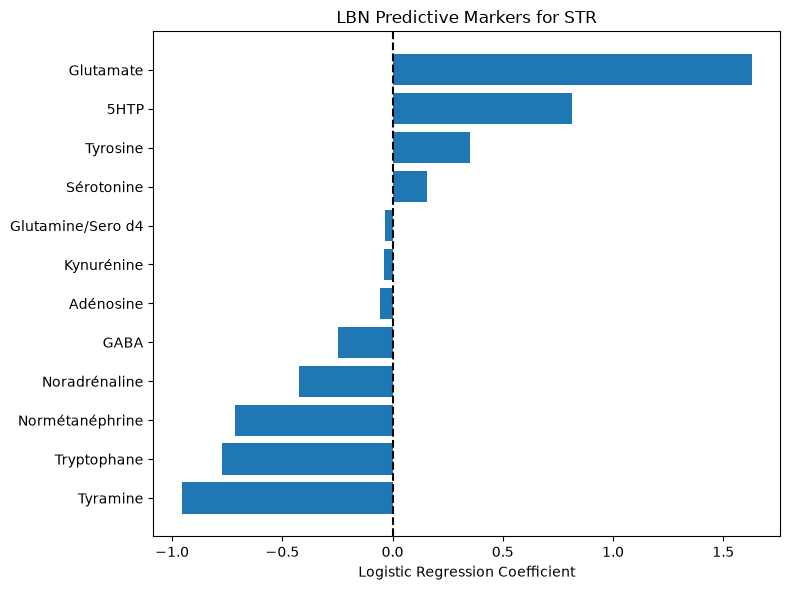

In [61]:
import matplotlib.pyplot as plt

coef = coef.sort_values("Coefficient")

plt.figure(figsize=(8,6))

plt.barh(
    coef["NT"],
    coef["Coefficient"]
)

plt.axvline(
    0,
    color="black",
    linestyle="--"
)

plt.xlabel("Logistic Regression Coefficient")
plt.title("LBN Predictive Markers for STR")

plt.tight_layout()
plt.show()

In [62]:
import numpy as np
import pandas as pd

from sklearn.utils import resample

n_boot = 1000

coef_boot = pd.DataFrame(
    columns=X_juv_str_log2.columns
)

for i in range(n_boot):

    # Bootstrap sample
    X_boot, Y_boot = resample(
        X_juv_str_log2,
        Y_juv_str2,
        replace=True,
        random_state=i
    )

    # Fit pipeline
    log_pipe.fit(X_boot, Y_boot)

    # Save coefficients
    coef_boot.loc[i] = log_pipe.named_steps["logreg"].coef_[0]

c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\U

In [63]:
summary = pd.DataFrame({
    "Mean": coef_boot.mean(),
    "Lower95": coef_boot.quantile(0.025),
    "Upper95": coef_boot.quantile(0.975)
})

summary

,Mean,Lower95,Upper95
5HTP,0.710127,0.197896,1.143026
Adénosine,-0.163727,-0.768358,0.400642
GABA,-0.173064,-0.571697,0.306376
Glutamate,1.444721,0.884214,1.881008
Glutamine/Sero d4,0.092106,-0.556052,0.731794
Kynurénine,0.040185,-0.492554,0.733554
Noradrénaline,-0.295852,-0.747965,0.156724
Normétanéphrine,-0.650909,-1.140496,-0.099288
Sérotonine,0.220078,-0.277282,0.675668
Tryptophane,-0.636308,-1.132071,-0.038174


### Random Forest

---

#### For the PFC

In [ ]:
rf_pipe = Pipeline([
    ("rf", RandomForestClassifier(
    n_estimators=1000, #Number of trees.
    max_depth=2, #Each tree can only make 2 splits.
    min_samples_leaf=4, #Minimum animals at the end of a branch.
    min_samples_split=8, #Minimum animals to consider a split.
    max_features="sqrt", #Number of features to consider at each split. Random Forest does NOT examine all variables.
    #If every tree always sees all NTs:become very similar. The forest loses diversity. Random feature selection creates more independent trees.
    class_weight="balanced", #Balance the classes.
    random_state=42 #Fixes randomness.
    ))
])

#Cross-validation strategy is a technique used to check how well a ML model performs on unseen data while preventing overfitting. 
# RepeatedStratifiedKFold is a specific method that combines stratified K-fold cross-validation with multiple repetitions to provide a more robust estimate of model performance, especially for imbalanced datasets.
# Stratified K-fold means that the folds are made by preserving the percentage of samples for each class. 
cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

rf_scores = cross_val_score(
    rf_pipe,
    X_juv_pfc_log,
    Y_juv_pfc,
    cv=cv,
    scoring="roc_auc" 
    #Receiver Operating Characteristic Area Under the Curve uses the true positive rate and false positive rate at various threshold settings to evaluate the performance of a binary classifier. 
    #The AUC represents the probability that a randomly chosen positive instance is ranked higher than a randomly chosen negative instance by the model.
    #AUC is the probability that: a randomly chosen LBN animal receives a higher predicted score than a randomly chosen CONT animal.
    n_jobs=-1
)

print("===== Random Forest =====")
print("Fold AUCs:", np.round(rf_scores, 3))
print(f"Mean AUC = {rf_scores.mean():.3f}")
print(f"SD = {rf_scores.std():.3f}")

===== Random Forest =====
Fold AUCs: [0.75  0.375 0.5   0.5   0.333 0.5   0.375 0.333 0.833 0.5   0.25  0.
 0.833 0.833 0.    0.25  0.5   0.    0.333 0.833 0.625 0.375 0.667 0.333
 0.5   0.5   0.25  0.333 0.333 0.5   0.625 0.5   0.    0.    0.    0.375
 0.25  0.333 0.167 0.5   0.125 0.375 0.333 0.5   0.667 0.25  0.375 0.333
 0.333 0.5   0.75  0.25  0.5   0.5   0.333 0.25  0.625 0.833 0.5   0.
 0.75  0.5   0.667 0.    0.167 0.375 0.25  0.5   0.    0.833 0.5   0.
 0.5   0.167 0.5   0.25  0.875 0.667 0.    0.5   0.75  0.75  0.333 0.5
 0.333 0.375 0.75  0.    0.833 0.333 0.5   0.25  0.833 0.333 0.333 0.75
 0.25  0.667 0.167 0.5  ]
Mean AUC = 0.419
SD = 0.242


In [65]:
rf_pipe.fit(X_juv_pfc_log, Y_juv_pfc)

rf = rf_pipe.named_steps["rf"]

rf_importance = pd.DataFrame({
    "NT": X_juv_pfc_log.columns,
    "Importance": rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance = rf_importance.sort_values(by="Importance", ascending=False)

print(rf_importance)

                   NT  Importance
0                5HTP    0.147877
10           Tyramine    0.103627
3           Glutamate    0.101279
2                GABA    0.098501
5          Kynurénine    0.088983
9         Tryptophane    0.082703
4   Glutamine/Sero d4    0.072999
7     Normétanéphrine    0.071787
8          Sérotonine    0.064830
11           Tyrosine    0.061822
6       Noradrénaline    0.052822
1           Adénosine    0.052770


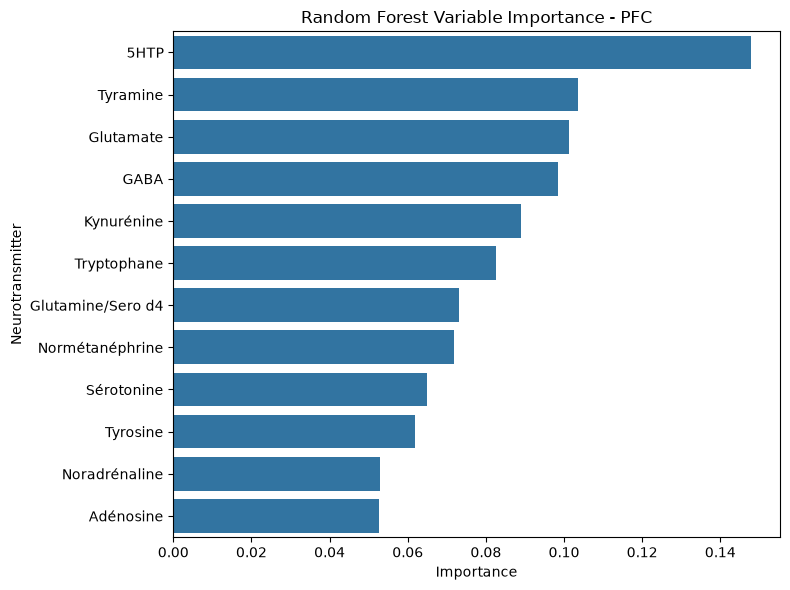

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.barplot(
    data=rf_importance,
    x="Importance",
    y="NT"
)

plt.title("Random Forest Variable Importance - PFC")
plt.xlabel("Importance")
plt.ylabel("Neurotransmitter")

plt.tight_layout()
plt.show()

c:\Users\lsrinivassan\Documents\Stage 2026 NTS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


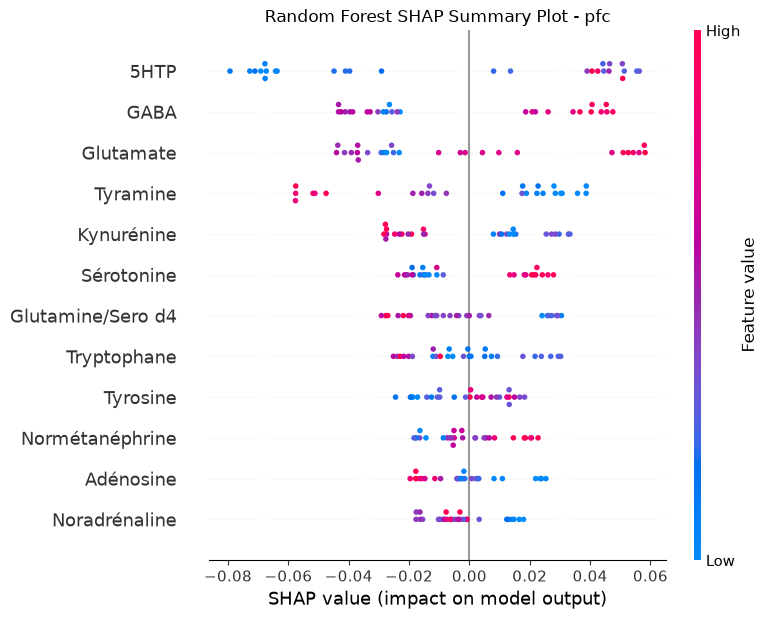

In [67]:
import pandas as pd
import shap
import matplotlib.pyplot as plt



X_imp = pd.DataFrame(
    X_juv_pfc_log,
    columns=X_juv_pfc_log.columns
)

# Extract tuned RF
rf = rf_pipe.named_steps["rf"]

# SHAP
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_imp)

# Binary classification
shap_class1 = shap_values[:, :, 1]

# Plot
shap.summary_plot(
    shap_class1,
    X_imp,
    show=False
)

plt.title("Random Forest SHAP Summary Plot - pfc")
plt.tight_layout()
plt.show()


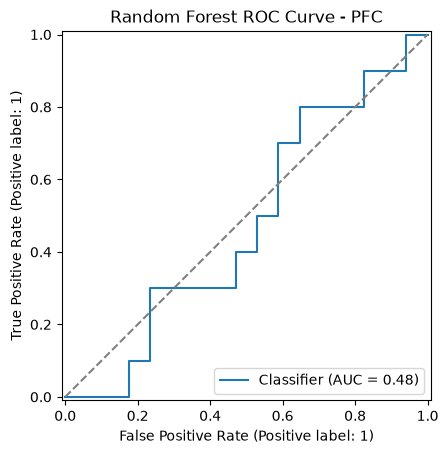

In [68]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    rf_pipe,
    X_juv_pfc_log,
    Y_juv_pfc,
    cv=cv,
    method="predict_proba"
)[:, 1]

RocCurveDisplay.from_predictions(
    Y_juv_pfc,
    y_prob
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="grey",
    label="Random classifier"
)

plt.title("Random Forest ROC Curve - PFC")
plt.show()

---

#### For the HIP

In [ ]:
rf_pipe = Pipeline([
        ("rf", RandomForestClassifier(
        n_estimators=1000, #Number of trees.
        max_depth=2, #Each tree can only make 2 splits.
        min_samples_leaf=4, #Minimum animals at the end of a branch.
        min_samples_split=8, #Minimum animals to consider a split.
        max_features="sqrt", #Number of features to consider at each split. Random Forest does NOT examine all variables.
        #If every tree always sees all NTs:become very similar. The forest loses diversity. Random feature selection creates more independent trees.
        class_weight="balanced", #Balance the classes.
        random_state=42 #Fixes randomness.
        ))
])
cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

rf_scores = cross_val_score(
    rf_pipe,
    X_juv_hip_log,
    Y_juv_hip,
    cv=cv,
    scoring="roc_auc" 
    #Receiver Operating Characteristic Area Under the Curve uses the true positive rate and false positive rate at various threshold settings to evaluate the performance of a binary classifier. 
    #The AUC represents the probability that a randomly chosen positive instance is ranked higher than a randomly chosen negative instance by the model.
    #AUC is the probability that: a randomly chosen LBN animal receives a higher predicted score than a randomly chosen CONT animal.
    n_jobs=-1
)
print("===== Random Forest =====")
print("Fold AUCs:", np.round(rf_scores, 3))
print(f"Mean AUC = {rf_scores.mean():.3f}")
print(f"SD = {rf_scores.std():.3f}")

===== Random Forest =====
Fold AUCs: [0.75  0.875 1.    0.75  0.583 1.    0.875 0.688 0.688 1.    0.75  1.
 0.812 0.75  0.833 0.812 0.688 0.875 0.75  1.    0.812 1.    0.75  0.812
 0.583 0.688 1.    0.875 0.875 1.    0.812 0.875 0.75  0.938 0.75  0.875
 0.75  0.812 0.625 0.917 0.625 0.875 0.875 1.    0.75  0.75  0.812 0.75
 0.938 0.75  1.    0.75  0.875 0.688 0.833 0.688 0.875 0.938 0.875 0.75
 0.812 0.875 0.938 1.    0.917 1.    0.812 0.625 0.75  0.917 0.938 0.75
 1.    0.75  0.833 0.938 0.688 1.    0.875 0.667 0.938 0.875 0.625 0.938
 0.833 0.688 0.75  0.938 0.75  1.    0.875 0.75  0.875 0.875 0.75  0.75
 0.938 0.812 1.    0.917]
Mean AUC = 0.833
SD = 0.113


In [ ]:
rf_pipe.fit(X_juv_hip_log, Y_juv_hip)

rf = rf_pipe.named_steps["rf"]

rf_importance = pd.DataFrame({
    "NT": X_juv_hip_log.columns,
    "Importance": rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance = rf_importance.sort_values(by="Importance", ascending=False)

print(rf_importance)

                   NT  Importance
2                GABA    0.167281
0                5HTP    0.154781
4   Glutamine/Sero d4    0.141594
11           Tyrosine    0.108733
3           Glutamate    0.098960
9         Tryptophane    0.081217
7     Normétanéphrine    0.066695
5          Kynurénine    0.056923
10           Tyramine    0.040292
1           Adénosine    0.035904
6       Noradrénaline    0.024620
8          Sérotonine    0.023000


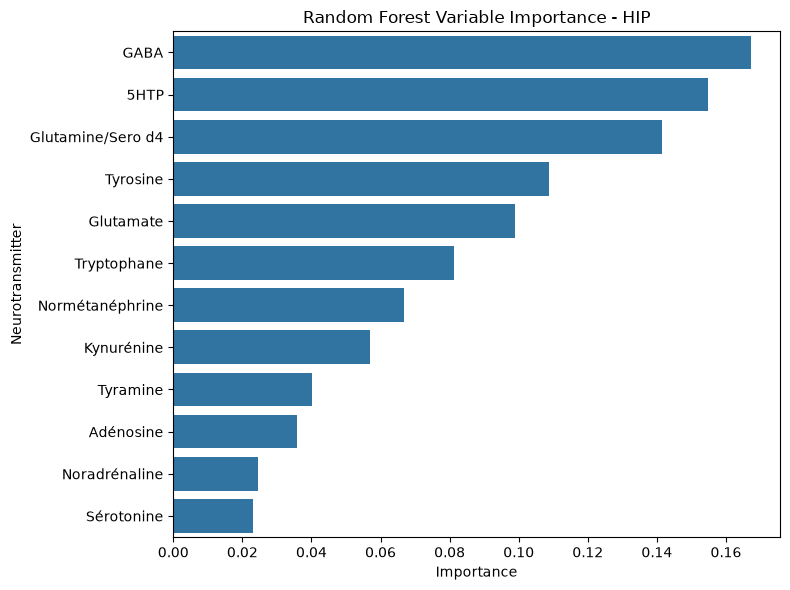

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.barplot(
    data=rf_importance,
    x="Importance",
    y="NT"
)

plt.title("Random Forest Variable Importance - HIP")
plt.xlabel("Importance")
plt.ylabel("Neurotransmitter")

plt.tight_layout()
plt.show()

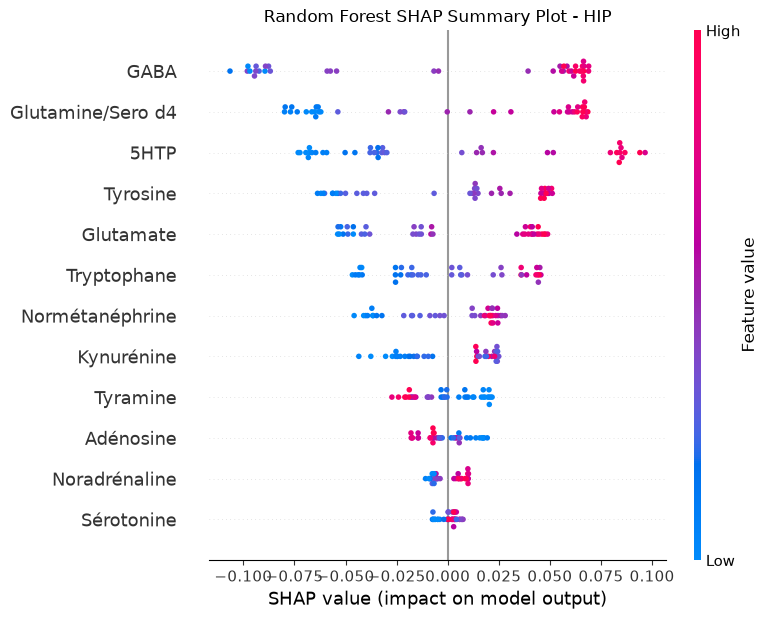

In [72]:
import pandas as pd
import shap
import matplotlib.pyplot as plt

X_imp = pd.DataFrame(
    X_juv_hip_log,
    columns=X_juv_hip_log.columns
)

# Extract tuned RF
rf = rf_pipe.named_steps["rf"]

# SHAP
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_imp)

# Binary classification
shap_class1 = shap_values[:, :, 1]

# Plot
shap.summary_plot(
    shap_class1,
    X_imp,
    show=False
)

plt.title("Random Forest SHAP Summary Plot - HIP")
plt.tight_layout()
plt.show()


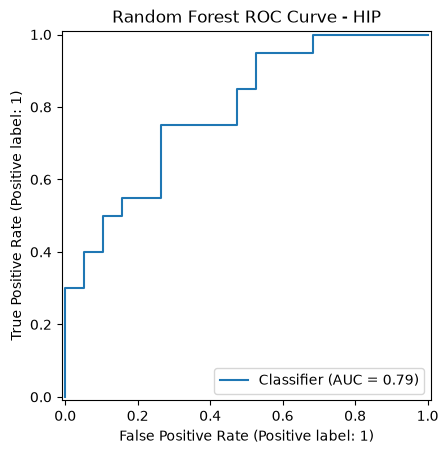

In [73]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

cv_roc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    rf_pipe,
    X_juv_hip_log,
    Y_juv_hip,
    cv=cv_roc,
    method="predict_proba"
)[:,1]

RocCurveDisplay.from_predictions(
    Y_juv_hip,
    y_prob
)

plt.title("Random Forest ROC Curve - HIP")
plt.show()

---

#### For the STR

In [74]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
import numpy as np

rf_pipe = Pipeline([
    ("rf", RandomForestClassifier(
        n_estimators=200,
        max_depth=3,
        min_samples_leaf=2,
        min_samples_split=4,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42
    ))
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

scores = cross_val_score(
    rf_pipe,
    X_juv_str_log,
    Y_juv_str,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("===== Random Forest =====")
print(f"Mean AUC = {scores.mean():.3f}")
print(f"SD = {scores.std():.3f}")

===== Random Forest =====
Mean AUC = 0.857
SD = 0.192


In [75]:
rf_pipe.fit(X_juv_str_log, Y_juv_str)

rf = rf_pipe.named_steps["rf"]

# Variable importance
rf_importance = pd.DataFrame({
    "NT": X_juv_str_log.columns,
    "Importance": rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

print(rf_importance)

                   NT  Importance
3           Glutamate    0.239680
0                5HTP    0.119059
10           Tyramine    0.108711
6       Noradrénaline    0.103337
4   Glutamine/Sero d4    0.080979
11           Tyrosine    0.078339
1           Adénosine    0.056569
7     Normétanéphrine    0.051276
2                GABA    0.043221
5          Kynurénine    0.041287
8          Sérotonine    0.039015
9         Tryptophane    0.038526


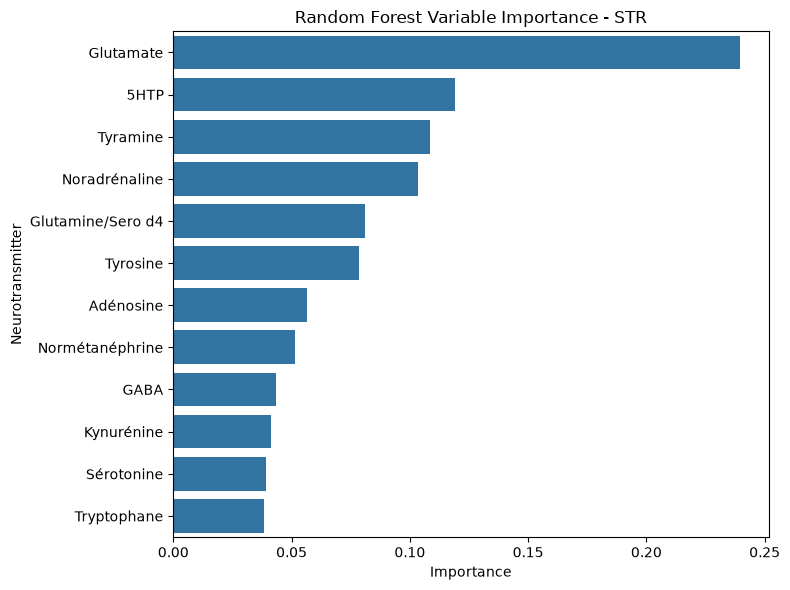

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.barplot(
    data=rf_importance,
    x="Importance",
    y="NT"
)

plt.title("Random Forest Variable Importance - STR")
plt.xlabel("Importance")
plt.ylabel("Neurotransmitter")

plt.tight_layout()
plt.show()

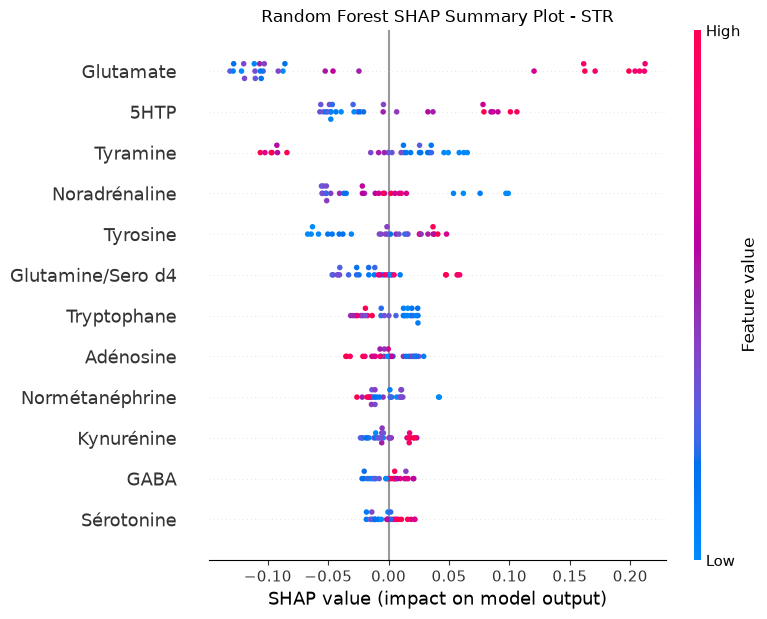

In [77]:
import pandas as pd
import shap
import matplotlib.pyplot as plt




X_imp = pd.DataFrame(
    X_juv_str_log,
    columns=X_juv_str_log.columns
)

# Extract tuned RF
rf = rf_pipe.named_steps["rf"]

# SHAP
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_imp)

# Binary classification
shap_class1 = shap_values[:, :, 1]

# Plot
shap.summary_plot(
    shap_class1,
    X_imp,
    show=False
)

plt.title("Random Forest SHAP Summary Plot - STR")
plt.tight_layout()
plt.show()

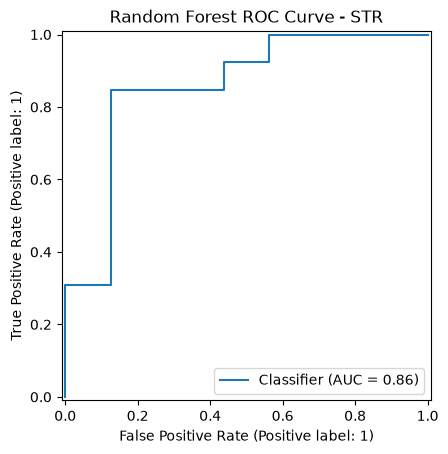

In [78]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

cv_roc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    rf_pipe,
    X_juv_str_log,
    Y_juv_str,
    cv=cv_roc,
    method="predict_proba"
)[:,1]

RocCurveDisplay.from_predictions(
    Y_juv_str,
    y_prob
)

plt.title("Random Forest ROC Curve - STR")
plt.show()